In [169]:
# Start by importing libraries
import requests
import re
import pandas as pd
from pandas import DataFrame


from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import numpy as np
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
import random as rd
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import tree
import graphviz
from sklearn.decomposition import LatentDirichletAllocation
import numpy as np

from sklearn.metrics import silhouette_samples, silhouette_score, accuracy_score
import sklearn
from sklearn.cluster import KMeans

from sklearn import preprocessing

import seaborn as sns
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import MDS
from mpl_toolkits.mplot3d import Axes3D
from scipy.cluster.hierarchy import ward, dendrogram
import networkx as nx

from sklearn.decomposition import PCA
from IPython.display import clear_output
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
import scipy.cluster.hierarchy as sch
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
import os
import zipfile
import pathlib
import glob

from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.svm import LinearSVC
from sklearn.svm import SVC
import matplotlib.colors as mcolors
import plotly.express as px

In [170]:
# Import Raw Master Data, easier to manipulate later if the CountVectorizer can be called
master_data = pd.read_csv('Raw Master Data.csv')
master_data.head()

,LABEL,Content
0,universal healthcare,universal basic income offers strings attached...
1,universal healthcare,universal basic income politically controversi...
2,universal healthcare,senators grilled robert kennedy trump pick hea...
3,universal healthcare,health secretary says reform poverty ambition ...
4,universal healthcare,initiative follows pressure from several artis...


In [171]:
# Then, CountVectorize the data to use with supervised models
MyCountV = CountVectorizer(
    input = 'content',
    lowercase = True,
    stop_words = 'english',
    max_features = 200, # to limit words to most important
    token_pattern = r'\b[a-zA-Z]{3,}\b' # to clean the data and remove words smaller than 3 characters

)


In [172]:
# Run the data through the Vectorizer
Vect1 = MyCountV.fit_transform(master_data['Content'])

# get feature names
CountVDF = pd.DataFrame(Vect1.toarray(), columns=MyCountV.get_feature_names_out())

In [173]:
# check results
print(CountVDF)

      able  absolutely  access  actually  afford  america  american  \
0        0           0       0         0       0        0         0   
1        0           0       0         0       0        0         0   
2        0           0       0         0       0        0         0   
3        0           0       0         0       0        0         0   
4        0           0       0         0       0        0         0   
...    ...         ...     ...       ...     ...      ...       ...   
2104     0           0       0         0       0        0         0   
2105     0           0       0         1       0        0         0   
2106     0           0       0         0       0        0         0   
2107     0           0       0         0       0        0         1   
2108     0           0       0         0       0        5         4   

      americans  arent  average  ...  wont  work  works  world  worse  \
0             0      0        0  ...     0     0      0      0      0   
1

In [174]:
# Append LABEL column back on by resetting index
CountVDF = CountVDF.reset_index(drop = True)

CountVDF.insert(0, 'LABEL', master_data['LABEL'])

In [175]:
# check
print(CountVDF)

                     LABEL  able  absolutely  access  actually  afford  \
0     universal healthcare     0           0       0         0       0   
1     universal healthcare     0           0       0         0       0   
2     universal healthcare     0           0       0         0       0   
3     universal healthcare     0           0       0         0       0   
4     universal healthcare     0           0       0         0       0   
...                    ...   ...         ...     ...       ...     ...   
2104             AskReddit     0           0       0         0       0   
2105             AskReddit     0           0       0         1       0   
2106             AskReddit     0           0       0         0       0   
2107             AskReddit     0           0       0         0       0   
2108  universal healthcare     0           0       0         0       0   

      america  american  americans  arent  ...  wont  work  works  world  \
0           0         0          0 

In [176]:
# Data for putting through models is now created
# Now to train/test split the dataset, into training data and testing data
Training_Data, Testing_Data = train_test_split(CountVDF, test_size = 0.4, random_state = 239)

# Separate the labels
Training_Label = Training_Data['LABEL']
Training_Data = Training_Data.drop(columns = ['LABEL'])

Testing_Label = Testing_Data['LABEL']
Testing_Data = Testing_Data.drop(columns = ['LABEL'])

# check results
print('Training Data:', Training_Data)
print('Training Labels:', Training_Label)

print('Testing Data:', Testing_Data)
print('Testing Labels:', Testing_Label)

Training Data:       able  absolutely  access  actually  afford  america  american  \
1032     0           0       0         0       0        0         0   
1430     0           0       0         0       0        0         0   
1022     0           0       0         0       0        0         0   
377      0           0       0         0       0        0         0   
1406     0           0       0         0       0        0         0   
...    ...         ...     ...       ...     ...      ...       ...   
131      0           0       0         0       0        0         0   
1670     0           1       0         0       0        0         0   
545      0           0       0         0       0        0         0   
904      0           0       0         0       0        0         0   
1420     0           0       0         0       0        0         0   

      americans  arent  average  ...  wont  work  works  world  worse  \
1032          0      0        0  ...     1     0      0    

In [177]:
# Naive Bayes - Multinomial

# Instantiate the model
MyMN = MultinomialNB()

# Train the model

My_MN_Model = MyMN.fit(Training_Data, Training_Label)
# show training
print(My_MN_Model)
print(My_MN_Model.classes_)

MultinomialNB()
['AskReddit' 'Conservative' 'Liberal' 'for-profit healthcare'
 'health equity' 'medicaid' 'private healthcare' 'privatized healthcare'
 'socialized medicine' 'universal health coverage' 'universal healthcare']


In [178]:
# Create predictions
Predictions_MN=My_MN_Model.predict(Testing_Data)
print(Predictions_MN)

# Actual probability
print("The Multinomial NB Model Prediction Probabilities are:")
print(My_MN_Model.predict_proba(Testing_Data).round(3))

['Liberal' 'Conservative' 'Liberal' 'AskReddit' 'medicaid' 'AskReddit'
 'AskReddit' 'AskReddit' 'for-profit healthcare' 'AskReddit'
 'private healthcare' 'AskReddit' 'Conservative' 'AskReddit'
 'Conservative' 'AskReddit' 'AskReddit' 'Conservative' 'AskReddit'
 'health equity' 'medicaid' 'AskReddit' 'AskReddit' 'Conservative'
 'Conservative' 'AskReddit' 'AskReddit' 'AskReddit' 'AskReddit'
 'private healthcare' 'AskReddit' 'Conservative' 'AskReddit' 'AskReddit'
 'Liberal' 'Liberal' 'AskReddit' 'AskReddit' 'AskReddit' 'AskReddit'
 'Liberal' 'Conservative' 'Conservative' 'Liberal' 'medicaid'
 'Conservative' 'private healthcare' 'Conservative' 'medicaid' 'AskReddit'
 'universal healthcare' 'Liberal' 'AskReddit' 'privatized healthcare'
 'AskReddit' 'Conservative' 'AskReddit' 'universal healthcare' 'AskReddit'
 'AskReddit' 'Liberal' 'AskReddit' 'AskReddit' 'universal healthcare'
 'AskReddit' 'AskReddit' 'AskReddit' 'Conservative' 'medicaid' 'AskReddit'
 'AskReddit' 'AskReddit' 'AskReddit' 'Co

In [179]:
# Confusion Matrix
CM_MN = confusion_matrix(Testing_Label, Predictions_MN)
print(CM_MN)

[[199  27  13   2   2   0   0   2   0   2   3]
 [ 69  96  24   1   0   1   1   0   0   1   1]
 [ 62  34  33   0   0   1   0   0   0   0   0]
 [ 17   6   1   5   1   4   2   0   0   1   4]
 [ 13   6   1   0   7   7   1   0   0   2   2]
 [  6   4   0   1   2  24   0   0   0   0   1]
 [ 17  10   7   0   2   2   3   0   0   0   5]
 [  5   3   0   0   0   3   0   0   0   1   3]
 [  4   2   1   0   0   2   1   0   0   0   0]
 [ 16   1   0   1   1   3   0   0   0  12   9]
 [ 19   4   4   2   2   5   0   0   0   1   1]]


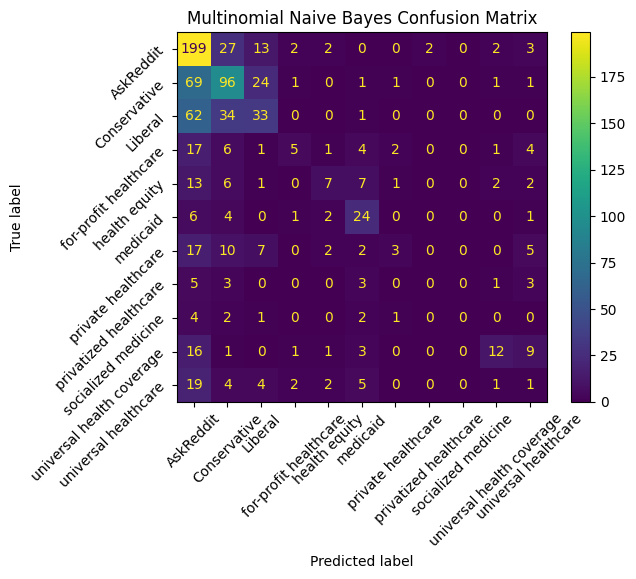

In [180]:
# Confusion Matrix Display
disp1 = ConfusionMatrixDisplay(confusion_matrix=CM_MN, display_labels=My_MN_Model.classes_)
disp1.plot()
plt.title("Multinomial Naive Bayes Confusion Matrix")
plt.xticks(rotation = 45)
plt.yticks(rotation = 45)
plt.show()

In [181]:
# Get Model Accuracy score
print('The Multinomial NB Accuracy Score is:', accuracy_score(Predictions_MN, Testing_Label))

The Multinomial NB Accuracy Score is: 0.45023696682464454


In [182]:
# Not great! But maybe decision Trees will do better
# There will be 3 different trees created
# Start with 1
# instantiate DT model
MyDT1=DecisionTreeClassifier(criterion='entropy',
                            splitter='random',
                            max_depth=5, # To ensure readable, clear results
                            min_samples_split=2,
                            min_samples_leaf=1,
                            min_weight_fraction_leaf=0.0,
                            max_features=None,
                            random_state=None,
                            max_leaf_nodes=10,
                            min_impurity_decrease=0.0,
                            class_weight=None)

In [183]:
# train the tree
MyDT1.fit(Training_Data, Training_Label)

DecisionTreeClassifier(criterion='entropy', max_depth=5, max_leaf_nodes=10,
                       splitter='random')

In [184]:
# get results
FeatureNames=Training_Data.columns.values # get feature names

ClassNames=MyDT1.classes_ # class names


The Decision Tree Model Prediction Probabilities are:
[[0.328 0.185 0.167 ... 0.016 0.058 0.059]
 [0.328 0.185 0.167 ... 0.016 0.058 0.059]
 [0.517 0.331 0.152 ... 0.    0.    0.   ]
 ...
 [0.517 0.331 0.152 ... 0.    0.    0.   ]
 [0.328 0.185 0.167 ... 0.016 0.058 0.059]
 [0.328 0.185 0.167 ... 0.016 0.058 0.059]]
[[241   3   1   0   0   5   0   0   0   0   0]
 [173  13   1   0   0   7   0   0   0   0   0]
 [122   4   1   0   0   3   0   0   0   0   0]
 [ 36   0   0   0   0   3   0   0   0   0   2]
 [ 26   0   0   0   0  12   0   0   0   0   1]
 [ 16   0   0   0   0  22   0   0   0   0   0]
 [ 45   0   0   0   0   1   0   0   0   0   0]
 [ 13   0   0   0   0   2   0   0   0   0   0]
 [  8   0   0   0   0   2   0   0   0   0   0]
 [ 42   0   0   0   0   1   0   0   0   0   0]
 [ 32   0   0   0   0   5   0   0   0   1   0]]


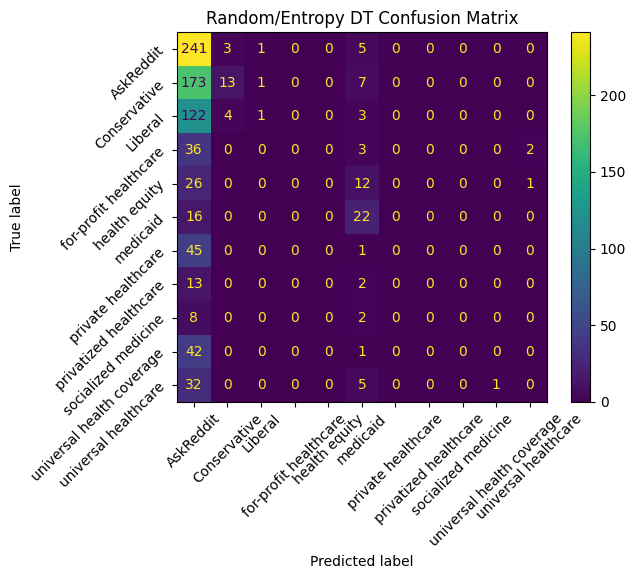

In [185]:
# Make predictions/Confusion Matrix
Predictions_DT1=MyDT1.predict(Testing_Data)

# probabilities
print("The Decision Tree Model Prediction Probabilities are:")
print(MyDT1.predict_proba(Testing_Data).round(3))

# Confusion Matrix
CM_DT1 = confusion_matrix(Testing_Label, Predictions_DT1)
print(CM_DT1)
# make it fancy

# Confusion Matrix Display
disp1 = ConfusionMatrixDisplay(confusion_matrix=CM_DT1, display_labels=MyDT1.classes_)
disp1.plot()
plt.title("Random/Entropy DT Confusion Matrix")
plt.xticks(rotation = 45)
plt.yticks(rotation = 45)
plt.show()

In [186]:
# Get Model Accuracy score
print('The Random/Entropy Accuracy Score is:', accuracy_score(Predictions_DT1, Testing_Label))

The Random/Entropy Accuracy Score is: 0.3281990521327014


In [187]:
# Graph the tree plot
MyPlot=tree.plot_tree(MyDT1,
                   feature_names=FeatureNames,
                   class_names=ClassNames,
                   filled=True,
                      fontsize = 3)

plt.savefig("DecisionTree1.jpg", dpi=400)


plt.close()

In [188]:
# Now to do two more
MyDT2=DecisionTreeClassifier(criterion='gini',
                            splitter='best',
                            max_depth=5, # To ensure readable, clear results
                            min_samples_split=2,
                            min_samples_leaf=1,
                            min_weight_fraction_leaf=0.0,
                            max_features=None,
                            random_state=None,
                            max_leaf_nodes=10,
                            min_impurity_decrease=0.0,
                            class_weight=None)

In [189]:
# train the tree
MyDT2.fit(Training_Data, Training_Label)

DecisionTreeClassifier(max_depth=5, max_leaf_nodes=10)

In [190]:
# get results
FeatureNames2=Training_Data.columns.values # get feature names

ClassNames2=MyDT2.classes_ # class names


The Decision Tree Second Model Prediction Probabilities are:
[[0.327 0.163 0.169 ... 0.016 0.053 0.063]
 [0.327 0.163 0.169 ... 0.016 0.053 0.063]
 [0.327 0.163 0.169 ... 0.016 0.053 0.063]
 ...
 [0.574 0.205 0.164 ... 0.    0.015 0.01 ]
 [0.574 0.205 0.164 ... 0.    0.015 0.01 ]
 [0.574 0.205 0.164 ... 0.    0.015 0.01 ]]
[[229  21   0   0   0   0   0   0   0   0   0]
 [128  65   0   0   0   1   0   0   0   0   0]
 [112  18   0   0   0   0   0   0   0   0   0]
 [ 35   1   0   0   0   3   0   0   0   0   2]
 [ 26   0   0   0   0  12   0   0   0   0   1]
 [ 22   4   0   0   0  12   0   0   0   0   0]
 [ 40   5   0   0   0   1   0   0   0   0   0]
 [ 12   1   0   0   0   2   0   0   0   0   0]
 [  8   0   0   0   0   2   0   0   0   0   0]
 [ 40   2   0   0   0   1   0   0   0   0   0]
 [ 30   2   0   0   0   6   0   0   0   0   0]]


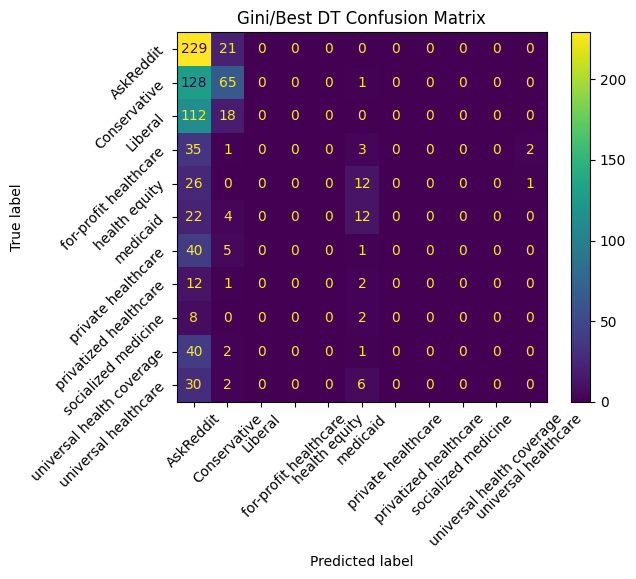

In [191]:
# Make predictions/Confusion Matrix
Predictions_DT2=MyDT2.predict(Testing_Data)

# probabilities
print("The Decision Tree Second Model Prediction Probabilities are:")
print(MyDT2.predict_proba(Testing_Data).round(3))

# Confusion Matrix
CM_DT2 = confusion_matrix(Testing_Label, Predictions_DT2)
print(CM_DT2)
# make it fancy

# Confusion Matrix Display
disp2 = ConfusionMatrixDisplay(confusion_matrix=CM_DT2, display_labels=MyDT2.classes_)
disp2.plot()
plt.title("Gini/Best DT Confusion Matrix")
plt.xticks(rotation = 45)
plt.yticks(rotation = 45)
plt.show()

In [192]:
# Get Model Accuracy score
print('The Gini/Best Accuracy Score is:', accuracy_score(Predictions_DT2, Testing_Label))

The Gini/Best Accuracy Score is: 0.36255924170616116


In [193]:
# Graph the second tree plot
MyPlot2=tree.plot_tree(MyDT2,
                   feature_names=FeatureNames2,
                   class_names=ClassNames2,
                   filled=True,
                      fontsize = 3)

plt.savefig("DecisionTree2.jpg", dpi=400)


plt.close()

In [194]:
# Now for the third tree
MyDT3=DecisionTreeClassifier(criterion='entropy',
                            splitter='best',
                            max_depth=5, # To ensure readable, clear results
                            min_samples_split=2,
                            min_samples_leaf=1,
                            min_weight_fraction_leaf=0.0,
                            max_features=None,
                            random_state=None,
                            max_leaf_nodes=10,
                            min_impurity_decrease=0.0,
                            class_weight=None)

In [195]:
# train the tree
MyDT3.fit(Training_Data, Training_Label)

DecisionTreeClassifier(criterion='entropy', max_depth=5, max_leaf_nodes=10)

In [196]:
# get results
FeatureNames3=Training_Data.columns.values # get feature names

ClassNames3=MyDT3.classes_ # class names


The Decision Tree Third Model Prediction Probabilities are:
[[0.314 0.18  0.17  ... 0.016 0.061 0.062]
 [0.564 0.295 0.141 ... 0.    0.    0.   ]
 [0.    0.385 0.615 ... 0.    0.    0.   ]
 ...
 [0.564 0.295 0.141 ... 0.    0.    0.   ]
 [0.314 0.18  0.17  ... 0.016 0.061 0.062]
 [0.314 0.18  0.17  ... 0.016 0.061 0.062]]
[[242   5   0   0   0   3   0   0   0   0   0]
 [158  23   7   0   0   6   0   0   0   0   0]
 [119   4   4   0   0   3   0   0   0   0   0]
 [ 36   0   0   0   0   5   0   0   0   0   0]
 [ 26   0   0   0   0  13   0   0   0   0   0]
 [ 16   0   0   0   0  22   0   0   0   0   0]
 [ 45   0   0   0   0   1   0   0   0   0   0]
 [ 13   0   0   0   0   2   0   0   0   0   0]
 [  8   0   0   0   0   2   0   0   0   0   0]
 [ 42   0   0   0   0   1   0   0   0   0   0]
 [ 32   0   0   0   0   5   0   0   0   1   0]]


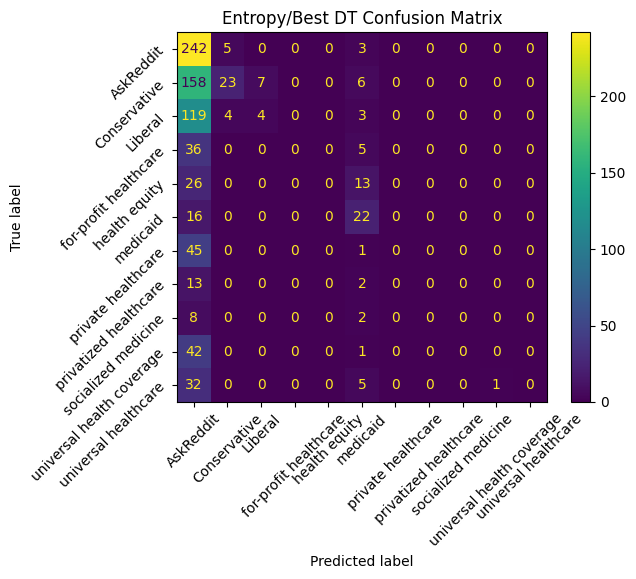

In [197]:
# Make predictions/Confusion Matrix
Predictions_DT3=MyDT3.predict(Testing_Data)

# probabilities
print("The Decision Tree Third Model Prediction Probabilities are:")
print(MyDT3.predict_proba(Testing_Data).round(3))

# Confusion Matrix
CM_DT3 = confusion_matrix(Testing_Label, Predictions_DT3)
print(CM_DT3)
# make it fancy

# Confusion Matrix Display
disp3 = ConfusionMatrixDisplay(confusion_matrix=CM_DT3, display_labels=MyDT3.classes_)
disp3.plot()
plt.title("Entropy/Best DT Confusion Matrix")
plt.xticks(rotation = 45)
plt.yticks(rotation = 45)
plt.show()

In [198]:
# Get Model Accuracy score
print('The Random/Best Accuracy Score is:', accuracy_score(Predictions_DT3, Testing_Label))

The Random/Best Accuracy Score is: 0.3447867298578199


In [199]:
# Graph the third tree plot
MyPlot3=tree.plot_tree(MyDT3,
                   feature_names=FeatureNames3,
                   class_names=ClassNames3,
                   filled=True,
                      fontsize = 3)

plt.savefig("DecisionTree3.jpg", dpi=400)


plt.close()

[Text(0.6911764705882353, 0.9166666666666666, 'trump <= 0.5\nentropy = 2.792\nsamples = 1265\nvalue = [411.0, 281.0, 203.0, 54.0, 60.0, 59.0, 49.0, 15.0\n18.0, 55.0, 60.0]\nclass = AskReddit'),
 Text(0.5, 0.75, 'dont <= 0.5\nentropy = 2.677\nsamples = 1198\nvalue = [411.0, 281.0, 202.0, 49.0, 46.0, 35.0, 44.0, 10.0\n14.0, 52.0, 54.0]\nclass = AskReddit'),
 Text(0.5955882352941176, 0.8333333333333333, 'True  '),
 Text(0.29411764705882354, 0.5833333333333334, 'medicaid <= 0.5\nentropy = 2.805\nsamples = 1019\nvalue = [323, 220, 172, 49, 46, 35, 44, 10, 14, 52, 54]\nclass = AskReddit'),
 Text(0.17647058823529413, 0.4166666666666667, 'pay <= 0.5\nentropy = 2.779\nsamples = 983\nvalue = [322, 205, 168, 48, 46, 21, 44, 10, 14, 52, 53]\nclass = AskReddit'),
 Text(0.11764705882352941, 0.25, 'removed <= 0.5\nentropy = 2.866\nsamples = 881\nvalue = [271, 175, 147, 48, 46, 21, 44, 10, 14, 52, 53]\nclass = AskReddit'),
 Text(0.058823529411764705, 0.08333333333333333, 'entropy = 2.881\nsamples = 85

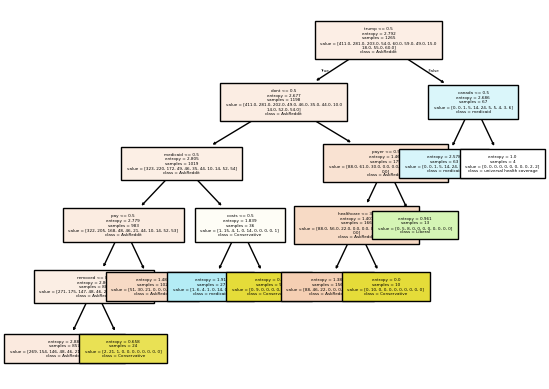

In [200]:
# For the plots, please open the jpg file to see the plots in full size
tree.plot_tree(MyDT3,
                   feature_names=FeatureNames3,
                   class_names=ClassNames3,
                   filled=True,
                      fontsize = 3)


The confusion matrix for Linear SVM is:
[[164  32  20  10   4   1   5   2   2   4   6]
 [ 53  92  24   3   3   5   3   0   1   3   7]
 [ 45  33  40   2   3   1   2   0   1   2   1]
 [ 15   7   0   5   1   2   6   0   0   1   4]
 [  8   3   0   0   7   6   2   2   0   6   5]
 [  5   2   1   1   2  20   2   3   0   0   2]
 [ 13   4   2   6   3   2  11   0   0   1   4]
 [  5   0   0   3   1   3   0   0   0   2   1]
 [  2   0   0   2   1   1   0   2   1   0   1]
 [ 11   1   0   3   4   0   2   0   2  14   6]
 [ 16   0   2   4   7   2   1   0   2   3   1]]





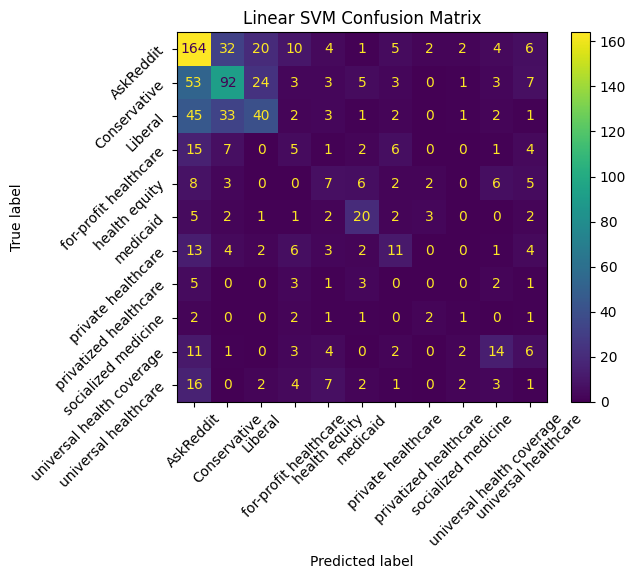

In [201]:
# Now for SVM
# The first kernel is the Linear SVM kernel
SVM_Model1=LinearSVC(C=3)

SVM_Model1.fit(Training_Data, Training_Label)
SVM_predict = SVM_Model1.predict(Testing_Data)

SVM_matrix = confusion_matrix(Testing_Label, SVM_Model1.predict(Testing_Data))
print("\nThe confusion matrix for Linear SVM is:")
print(SVM_matrix)
print("\n\n")

# Confusion Matrix Display
disp = ConfusionMatrixDisplay(confusion_matrix=SVM_matrix, display_labels=SVM_Model1.classes_)
disp.plot()
plt.title("Linear SVM Confusion Matrix")
plt.xticks(rotation = 45)
plt.yticks(rotation = 45)
plt.show()

In [202]:
# Get Model Accuracy score
print('The Linear SVC Accuracy Score is:', accuracy_score(SVM_predict, Testing_Label))

The Linear SVC Accuracy Score is: 0.4206161137440758



The confusion matrix rbf SVM is:
[[205  24  14   3   0   0   1   0   1   1   1]
 [ 86  89  16   2   0   0   0   0   0   1   0]
 [ 73  24  31   0   0   2   0   0   0   0   0]
 [ 22   5   1   2   3   2   2   0   0   1   3]
 [ 20   1   0   0  10   5   0   0   0   1   2]
 [ 10   3   0   1   6  18   0   0   0   0   0]
 [ 30   5   1   1   3   0   4   0   0   0   2]
 [  8   0   0   0   1   3   0   0   0   3   0]
 [  5   1   1   0   1   2   0   0   0   0   0]
 [ 21   0   1   0   4   0   0   0   0  14   3]
 [ 24   1   2   0   7   3   0   0   0   0   1]]





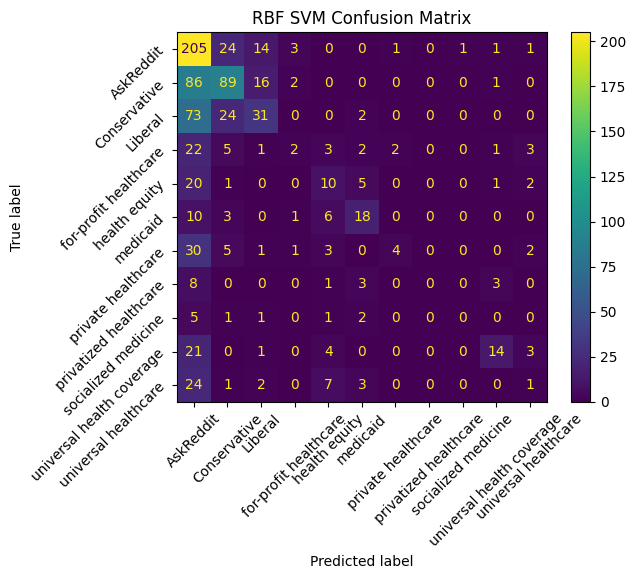

In [203]:
# Again for RBF Kernel
SVM_Model2=SVC(C=30, kernel='rbf', degree=3, gamma="auto")
SVM_Model2.fit(Training_Data, Training_Label)

SVM_predict2 = SVM_Model2.predict(Testing_Data)

SVM_matrix2 = confusion_matrix(Testing_Label, SVM_Model2.predict(Testing_Data))
print("\nThe confusion matrix rbf SVM is:")
print(SVM_matrix2)
print("\n\n")


disp = ConfusionMatrixDisplay(confusion_matrix=SVM_matrix2, display_labels=SVM_Model2.classes_)
disp.plot()
plt.title("RBF SVM Confusion Matrix")
plt.xticks(rotation = 45)
plt.yticks(rotation = 45)
plt.show()

In [204]:
# Get Model Accuracy score
print('The RBF SVM Accuracy Score is:', accuracy_score(SVM_predict2, Testing_Label))

The RBF SVM Accuracy Score is: 0.4431279620853081



The confusion matrix for poly SVM is:
[[243   3   4   0   0   0   0   0   0   0   0]
 [170  21   3   0   0   0   0   0   0   0   0]
 [121   4   5   0   0   0   0   0   0   0   0]
 [ 41   0   0   0   0   0   0   0   0   0   0]
 [ 39   0   0   0   0   0   0   0   0   0   0]
 [ 38   0   0   0   0   0   0   0   0   0   0]
 [ 46   0   0   0   0   0   0   0   0   0   0]
 [ 15   0   0   0   0   0   0   0   0   0   0]
 [ 10   0   0   0   0   0   0   0   0   0   0]
 [ 43   0   0   0   0   0   0   0   0   0   0]
 [ 38   0   0   0   0   0   0   0   0   0   0]]





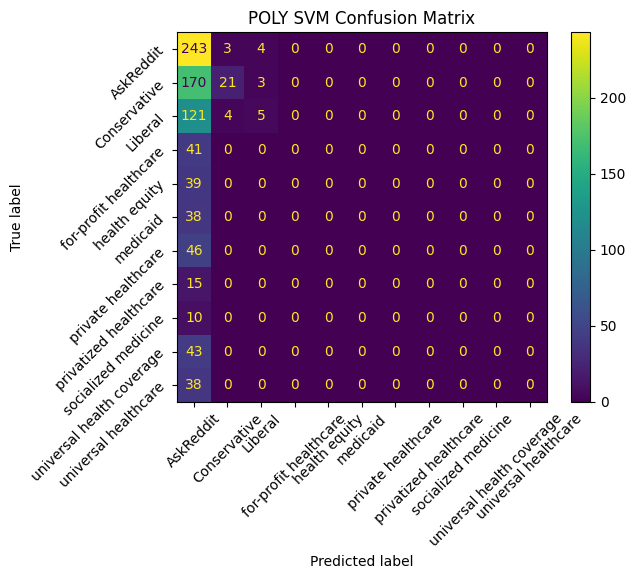

In [205]:
# Finally, run the POLY kernel
SVM_Model3=SVC(C=60, kernel='poly', degree=3, gamma="auto")
SVM_Model3.fit(Training_Data, Training_Label)

SVM_predict3 = SVM_Model3.predict(Testing_Data)



SVM_matrix3 = confusion_matrix(Testing_Label, SVM_Model3.predict(Testing_Data))
print("\nThe confusion matrix for poly SVM is:")
print(SVM_matrix3)
print("\n\n")

disp = ConfusionMatrixDisplay(confusion_matrix=SVM_matrix3, display_labels=SVM_Model3.classes_)
disp.plot()
plt.title("POLY SVM Confusion Matrix")
plt.xticks(rotation = 45)
plt.yticks(rotation = 45)
plt.show()

In [206]:
# Get Model Accuracy score
print('The POLY SVM Accuracy Score is:', accuracy_score(SVM_predict3, Testing_Label))

The POLY SVM Accuracy Score is: 0.3187203791469194


In [207]:
# Sentiment Analysis - Using Conservative as 'NEG' and Liberal as 'POS'
# isolate only conservative/liberal data
SentDF = master_data[master_data['LABEL'].isin(['Liberal', 'Conservative'])].reset_index(drop=True) # reset index to realign for labeling

SentDF.head()

,LABEL,Content
0,Conservative,i personally am not but what i ussually hear a...
1,Conservative,the real question is how do i know those taxes...
2,Conservative,im not opposed to a universal system were very...
3,Conservative,why put a bandaid on an artery bleed without a...
4,Conservative,i dont trust the federal government running th...


In [208]:
# Count Vectorize this dataset
Vect3 = MyCountV.fit_transform(SentDF['Content'])

# get feature names
CountVDF2 = pd.DataFrame(Vect3.toarray(), columns=MyCountV.get_feature_names_out())

In [209]:
# check results
print(CountVDF2)

     able  access  actual  actually  afford  agree  american  americans  \
0       0       0       0         0       0      0         0          0   
1       0       0       0         4       0      0         0          0   
2       0       0       0         0       0      0         0          0   
3       0       0       0         0       0      0         0          0   
4       1       0       0         0       0      0         0          0   
..    ...     ...     ...       ...     ...    ...       ...        ...   
803     0       0       0         0       0      1         0          0   
804     0       0       0         0       0      0         0          0   
805     0       0       0         0       0      0         0          0   
806     0       0       0         0       0      0         0          0   
807     0       0       0         0       0      0         0          0   

     arent  argument  ...  works  world  worse  wouldnt  wrong  year  years  \
0        0         0

In [210]:
# Append LABEL column back on by resetting index
CountVDF2 = CountVDF2.reset_index(drop = True)

CountVDF2.insert(0, 'LABEL', SentDF['LABEL'])

In [211]:
# check
print(CountVDF2)

            LABEL  able  access  actual  actually  afford  agree  american  \
0    Conservative     0       0       0         0       0      0         0   
1    Conservative     0       0       0         4       0      0         0   
2    Conservative     0       0       0         0       0      0         0   
3    Conservative     0       0       0         0       0      0         0   
4    Conservative     1       0       0         0       0      0         0   
..            ...   ...     ...     ...       ...     ...    ...       ...   
803       Liberal     0       0       0         0       0      1         0   
804       Liberal     0       0       0         0       0      0         0   
805       Liberal     0       0       0         0       0      0         0   
806       Liberal     0       0       0         0       0      0         0   
807       Liberal     0       0       0         0       0      0         0   

     americans  arent  ...  works  world  worse  wouldnt  wrong

In [212]:
# train/test split this too
Training_Data2, Testing_Data2 = train_test_split(CountVDF2, test_size = 0.4, random_state = 239)

# Separate the labels
Training_Label2 = Training_Data2['LABEL']
Training_Data2 = Training_Data2.drop(columns = ['LABEL'])

Testing_Label2 = Testing_Data2['LABEL']
Testing_Data2 = Testing_Data2.drop(columns = ['LABEL'])

# check results
print('Training Data 2:', Training_Data2)
print('Training Labels 2:', Training_Label2)

print('Testing Data 2:', Testing_Data2)
print('Testing Labels 2:', Testing_Label2)

Training Data 2:      able  access  actual  actually  afford  agree  american  americans  \
672     0       0       0         0       0      0         0          1   
544     0       0       0         0       0      0         0          0   
295     0       0       0         0       0      0         0          0   
182     0       0       0         0       0      0         0          0   
354     0       0       0         0       0      0         0          0   
..    ...     ...     ...       ...     ...    ...       ...        ...   
574     0       0       0         0       0      0         0          0   
646     0       0       0         0       0      0         0          0   
545     0       0       0         0       0      0         2          0   
396     0       0       0         0       0      0         0          0   
424     0       0       0         0       0      0         0          0   

     arent  argument  ...  works  world  worse  wouldnt  wrong  year  years  \
672


The confusion matrix for Linear SVM is:
[[123  58]
 [ 81  62]]





/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


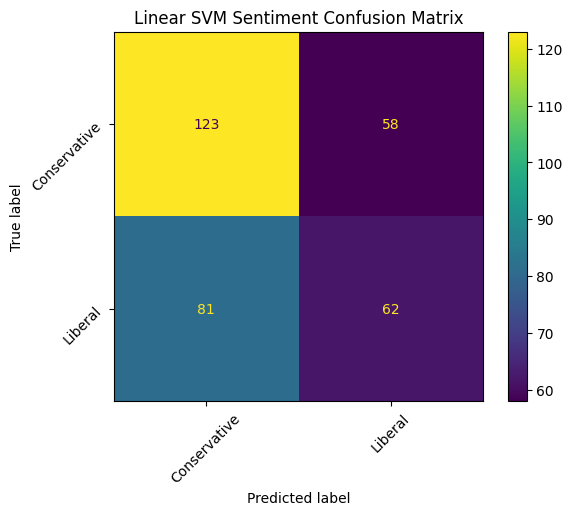

In [213]:
 # Linear SVM sentiment
 SVM_Model1=LinearSVC(C=100)

SVM_Model1.fit(Training_Data2, Training_Label2)
SVM_predict = SVM_Model1.predict(Testing_Data2)

SVM_matrix = confusion_matrix(Testing_Label2, SVM_Model1.predict(Testing_Data2))
print("\nThe confusion matrix for Linear SVM is:")
print(SVM_matrix)
print("\n\n")

# Confusion Matrix Display
disp = ConfusionMatrixDisplay(confusion_matrix=SVM_matrix, display_labels=SVM_Model1.classes_)
disp.plot()
plt.title("Linear SVM Sentiment Confusion Matrix")
plt.xticks(rotation = 45)
plt.yticks(rotation = 45)
plt.show()

In [214]:
# Get Model Accuracy score
print('The Linear Sentiment SVC Accuracy Score is:', accuracy_score(SVM_predict, Testing_Label2))

The Linear Sentiment SVC Accuracy Score is: 0.5709876543209876



The confusion matrix rbf SVM is:
[[137  44]
 [ 83  60]]





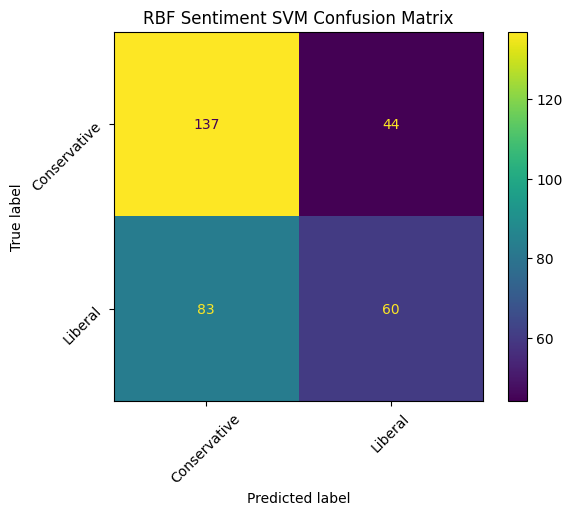

In [215]:
# Again for RBF Kernel
SVM_Model2=SVC(C=50, kernel='rbf', degree=3, gamma="auto")
SVM_Model2.fit(Training_Data2, Training_Label2)

SVM_predict2 = SVM_Model2.predict(Testing_Data2)

SVM_matrix2 = confusion_matrix(Testing_Label2, SVM_Model2.predict(Testing_Data2))
print("\nThe confusion matrix rbf SVM is:")
print(SVM_matrix2)
print("\n\n")


disp = ConfusionMatrixDisplay(confusion_matrix=SVM_matrix2, display_labels=SVM_Model2.classes_)
disp.plot()
plt.title("RBF Sentiment SVM Confusion Matrix")
plt.xticks(rotation = 45)
plt.yticks(rotation = 45)
plt.show()

In [216]:
# Get Model Accuracy score
print('The RBF Sentiment SVM Accuracy Score is:', accuracy_score(SVM_predict2, Testing_Label2))

The RBF Sentiment SVM Accuracy Score is: 0.6080246913580247



The confusion matrix for poly SVM is:
[[171  10]
 [136   7]]





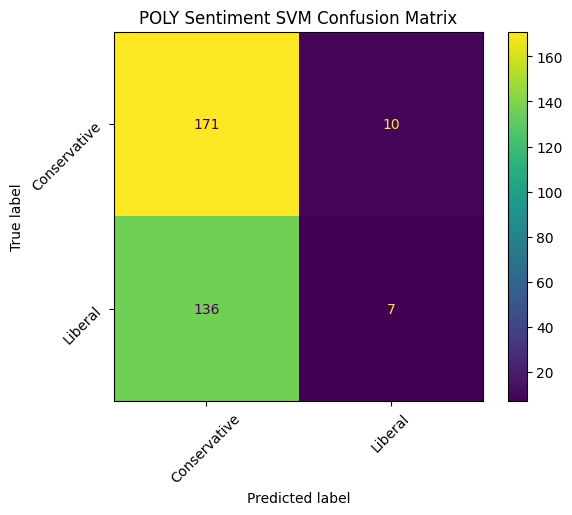

In [217]:
# Finally, run the POLY kernel
SVM_Model3=SVC(C=200, kernel='poly', degree=3, gamma="auto")
SVM_Model3.fit(Training_Data2, Training_Label2)

SVM_predict3 = SVM_Model3.predict(Testing_Data2)



SVM_matrix3 = confusion_matrix(Testing_Label2, SVM_Model3.predict(Testing_Data2))
print("\nThe confusion matrix for poly SVM is:")
print(SVM_matrix3)
print("\n\n")

disp = ConfusionMatrixDisplay(confusion_matrix=SVM_matrix3, display_labels=SVM_Model3.classes_)
disp.plot()
plt.title("POLY Sentiment SVM Confusion Matrix")
plt.xticks(rotation = 45)
plt.yticks(rotation = 45)
plt.show()

In [218]:
# Get Model Accuracy score
print('The POLY Sentiment SVM Accuracy Score is:', accuracy_score(SVM_predict3, Testing_Label2))

The POLY Sentiment SVM Accuracy Score is: 0.5493827160493827


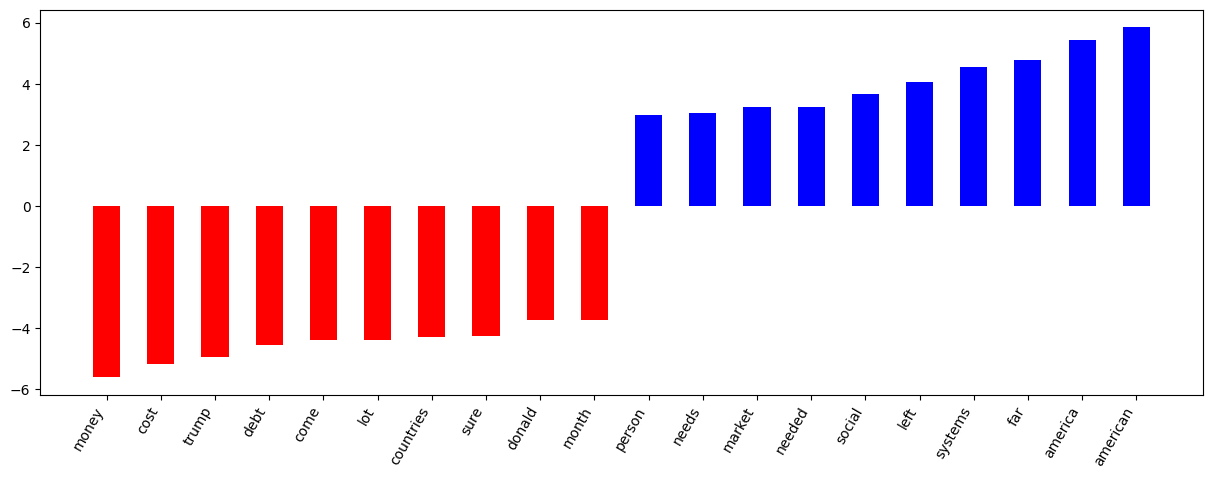

<Figure size 640x480 with 0 Axes>

In [224]:
# Visualization
def plot_coefficients(MODEL=SVM_Model1, COLNAMES=CountVDF.columns, top_features=10):
    ## Model if SVM MUST be SVC, RE: SVM_Model=LinearSVC(C=10)
    coef = MODEL.coef_.ravel()
    top_positive_coefficients = np.argsort(coef,axis=0)[-top_features:]
    top_negative_coefficients = np.argsort(coef,axis=0)[:top_features]
    top_coefficients = np.hstack([top_negative_coefficients, top_positive_coefficients])
    # create plot
    plt.figure(figsize=(15, 5))
    colors = ["red" if c < 0 else "blue" for c in coef[top_coefficients]]
    plt.bar(  x=  np.arange(2 * top_features)  , height=coef[top_coefficients], width=.5,  color=colors)
    feature_names = np.array(COLNAMES)
    plt.xticks(np.arange(0, (2*top_features)), feature_names[top_coefficients], rotation=60, ha="right")
    plt.show()


plot_coefficients()
plt.savefig('KeyWords.pdf')